# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Ecommerce Sales Analytics Dataset](https://www.kaggle.com/datasets/abbas829/ecommerce-sales-dataset/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/kaggle/input/datasets/abbas829/ecommerce-sales-dataset/ecommerce_sales_analytics_5000.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ecommerce_sales_analytics_5000.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## last Five row

In [4]:
df.tail()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


## Shape of our dataset

In [5]:
df.shape

(5000, 12)

## List out all columns

In [6]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

order_id              int64
order_date           object
customer_id           int64
product_category     object
region               object
quantity              int64
unit_price          float64
discount            float64
payment_method       object
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


## Check Null Value

In [9]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

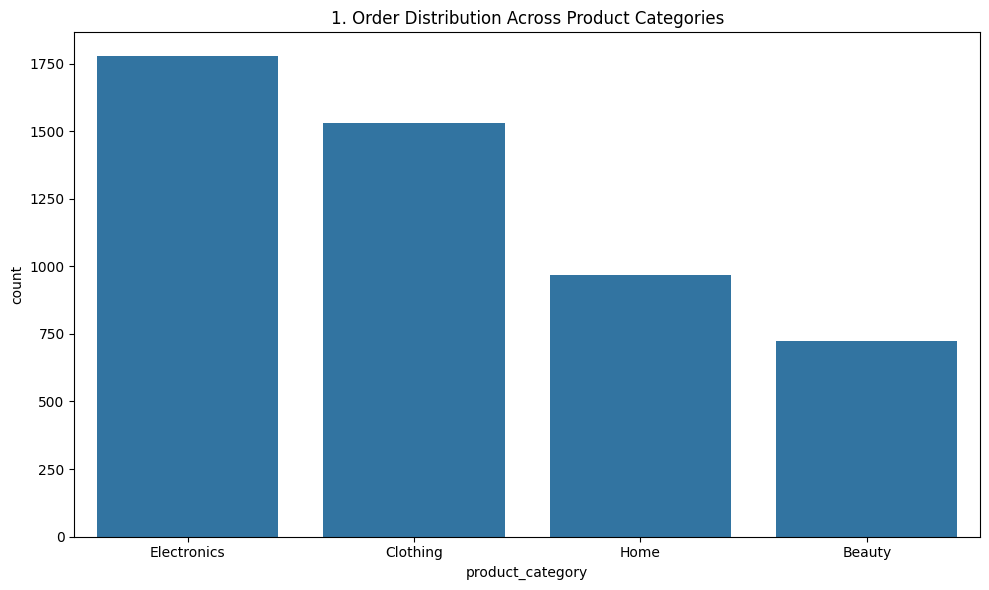

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='product_category', order=df['product_category'].value_counts().index)
plt.title(f'{plot_no}. Order Distribution Across Product Categories')
show_fig()
plot_no += 1

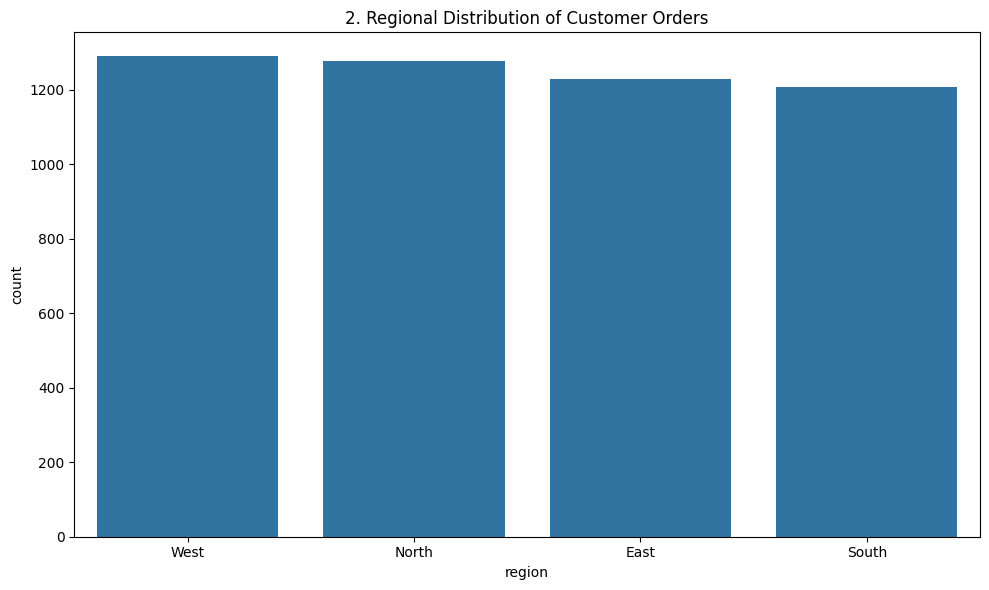

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='region', order=df['region'].value_counts().index)
plt.title(f'{plot_no}. Regional Distribution of Customer Orders')
show_fig()
plot_no += 1

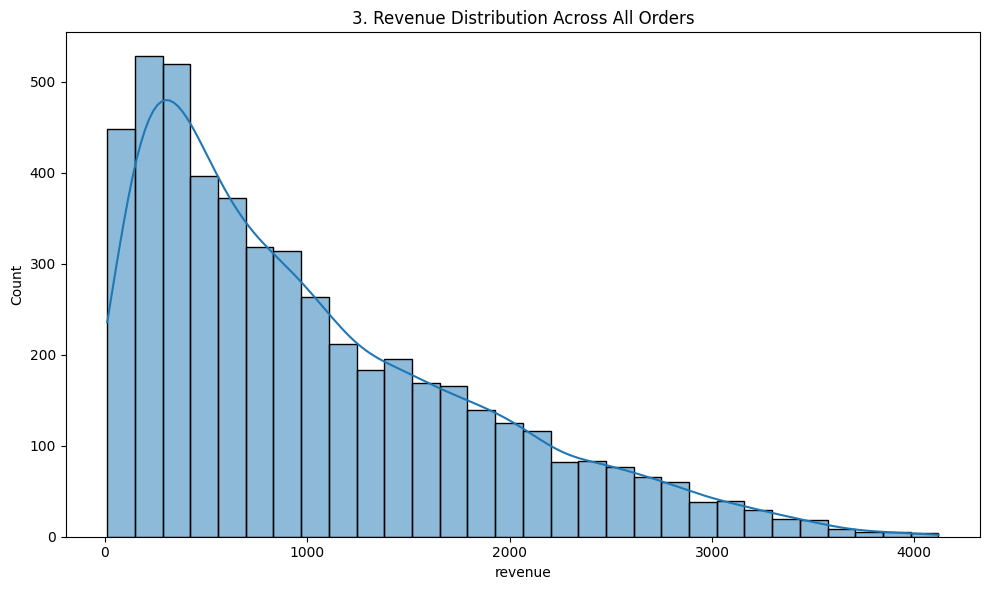

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['revenue'], bins=30, kde=True)
plt.title(f'{plot_no}. Revenue Distribution Across All Orders')
show_fig()
plot_no += 1

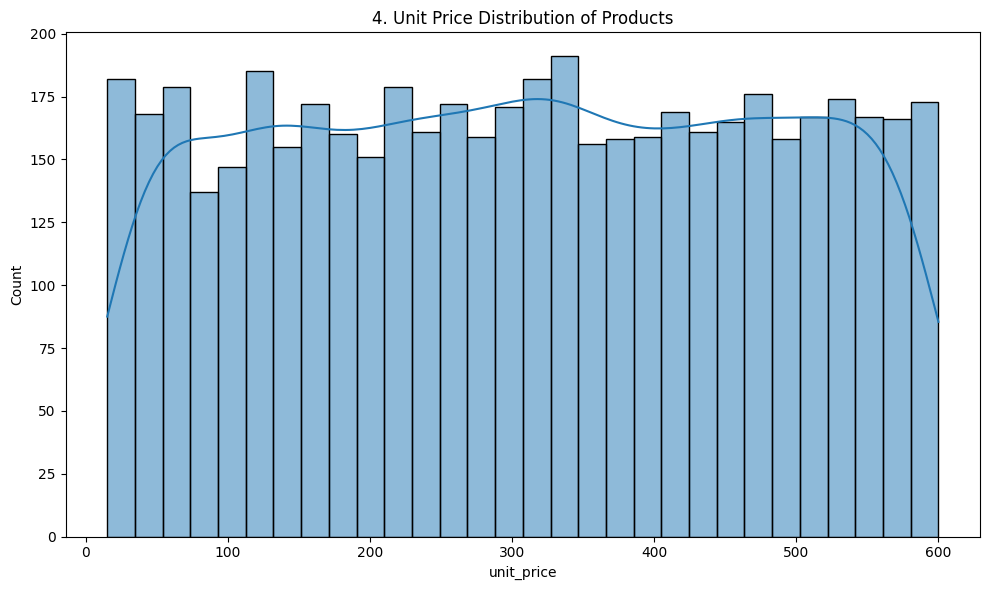

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['unit_price'], bins=30, kde=True)
plt.title(f'{plot_no}. Unit Price Distribution of Products')
show_fig()
plot_no += 1

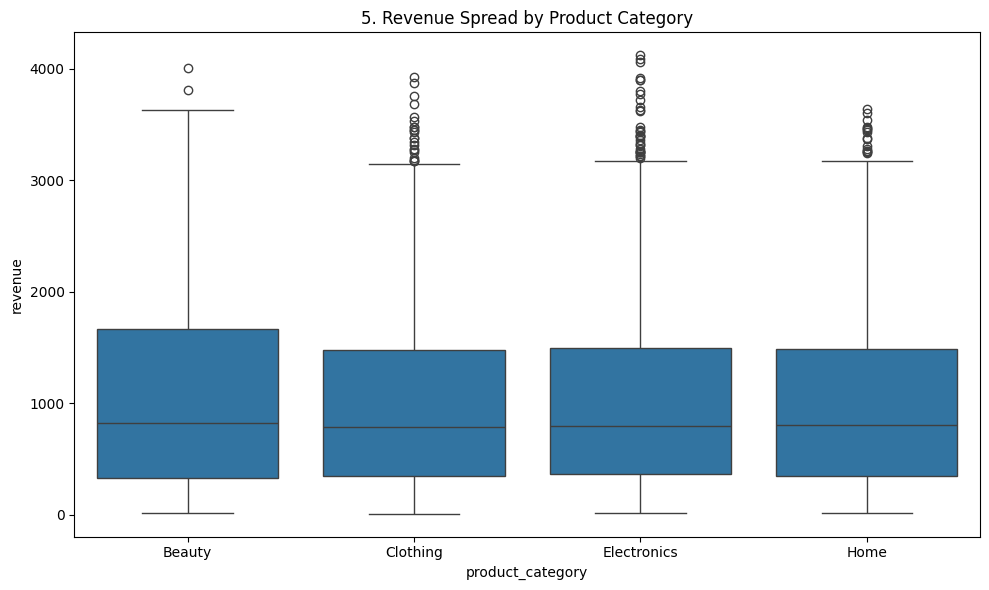

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='product_category', y='revenue')
plt.title(f'{plot_no}. Revenue Spread by Product Category')
show_fig()
plot_no += 1

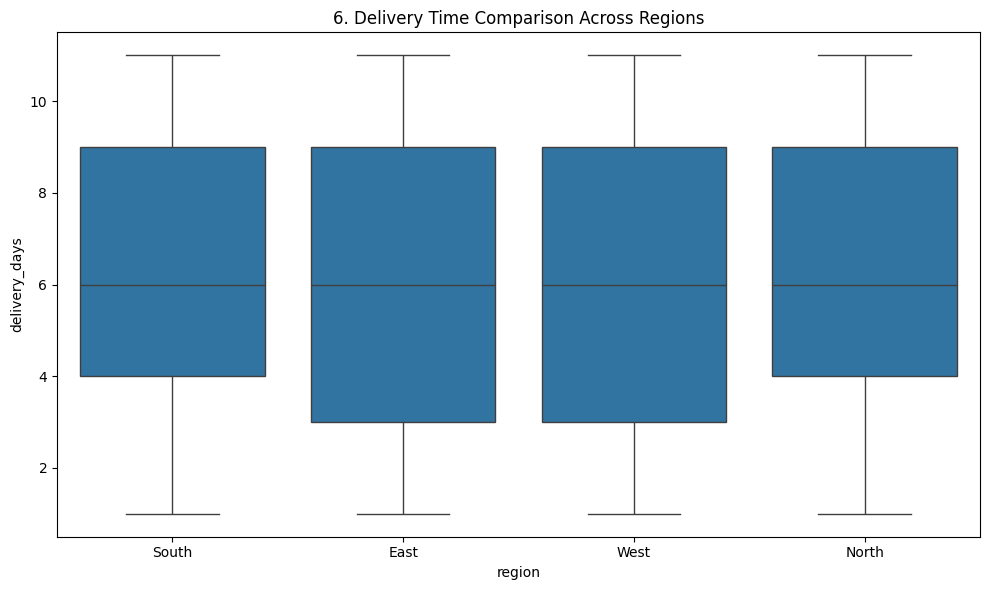

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='region', y='delivery_days')
plt.title(f'{plot_no}. Delivery Time Comparison Across Regions')
show_fig()
plot_no += 1

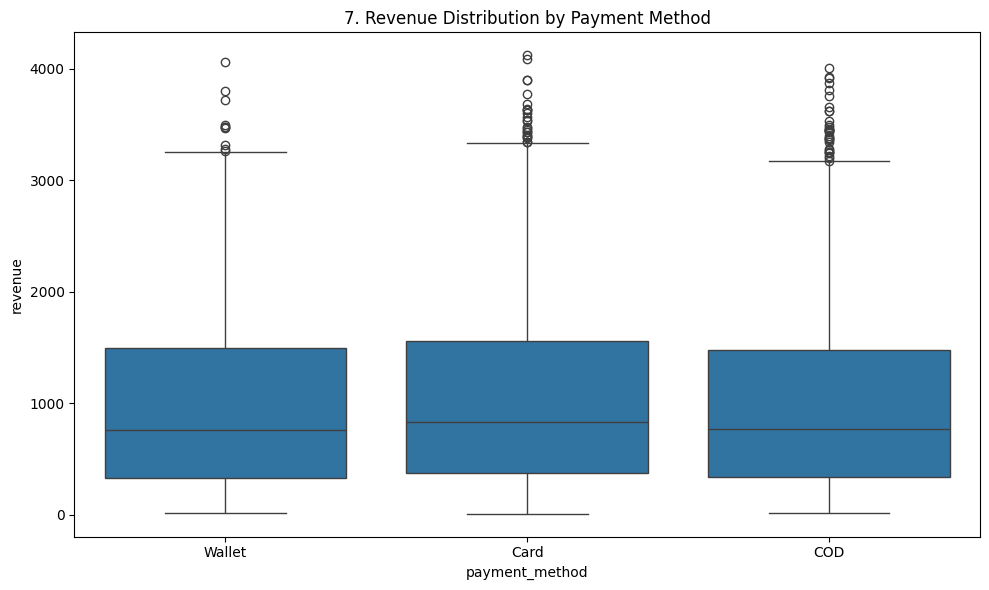

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='payment_method', y='revenue')
plt.title(f'{plot_no}. Revenue Distribution by Payment Method')
show_fig()
plot_no += 1

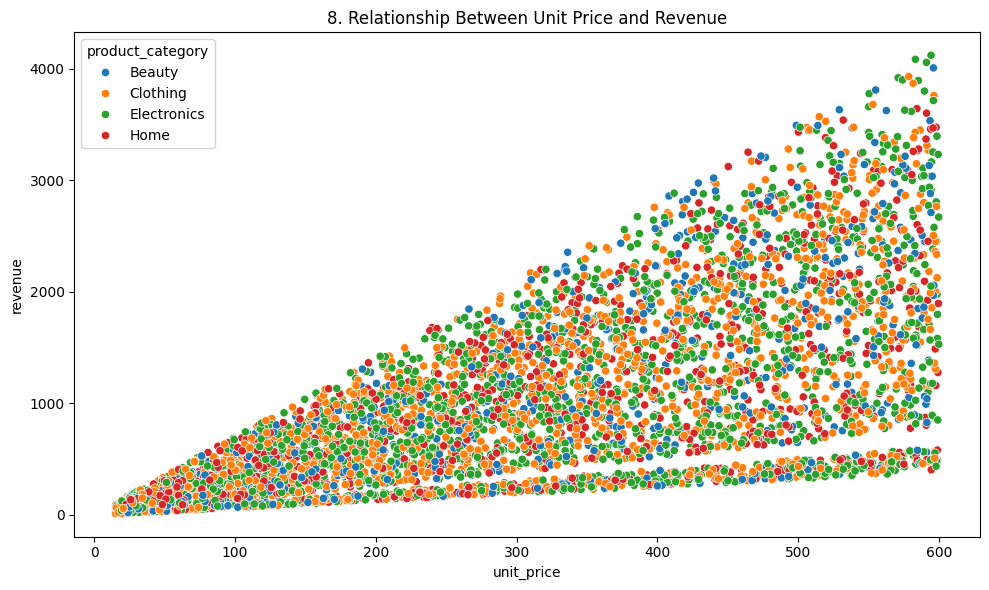

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='unit_price', y='revenue', hue='product_category')
plt.title(f'{plot_no}. Relationship Between Unit Price and Revenue')
show_fig()
plot_no += 1

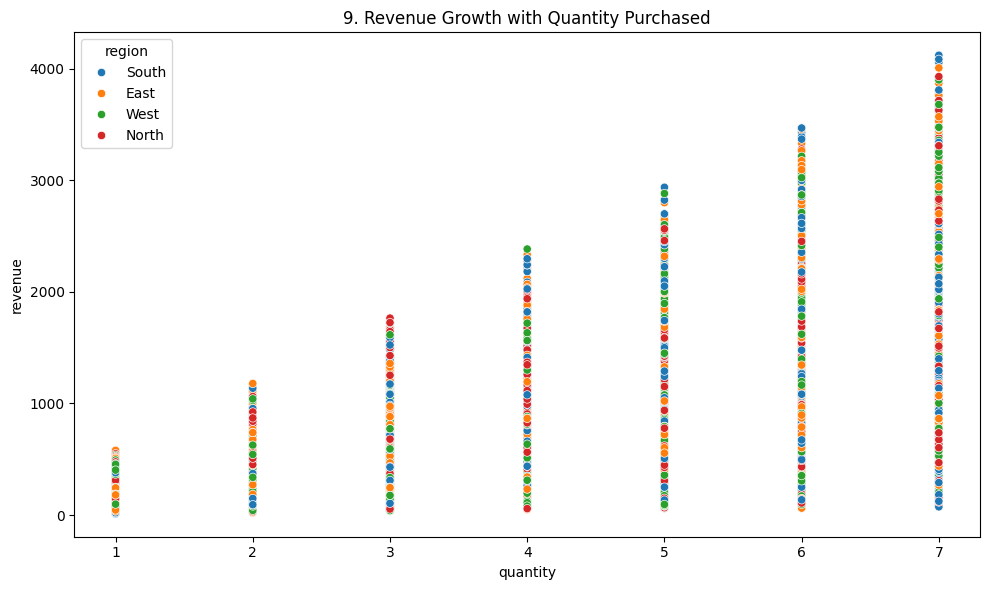

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='quantity', y='revenue', hue='region')
plt.title(f'{plot_no}. Revenue Growth with Quantity Purchased')
show_fig()
plot_no += 1

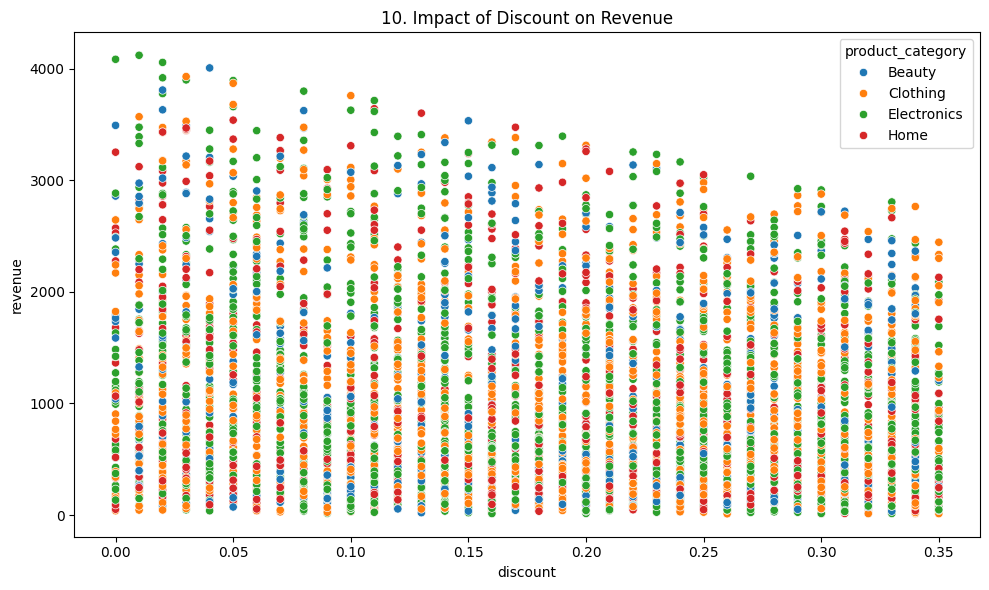

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='discount', y='revenue', hue='product_category')
plt.title(f'{plot_no}. Impact of Discount on Revenue')
show_fig()
plot_no += 1

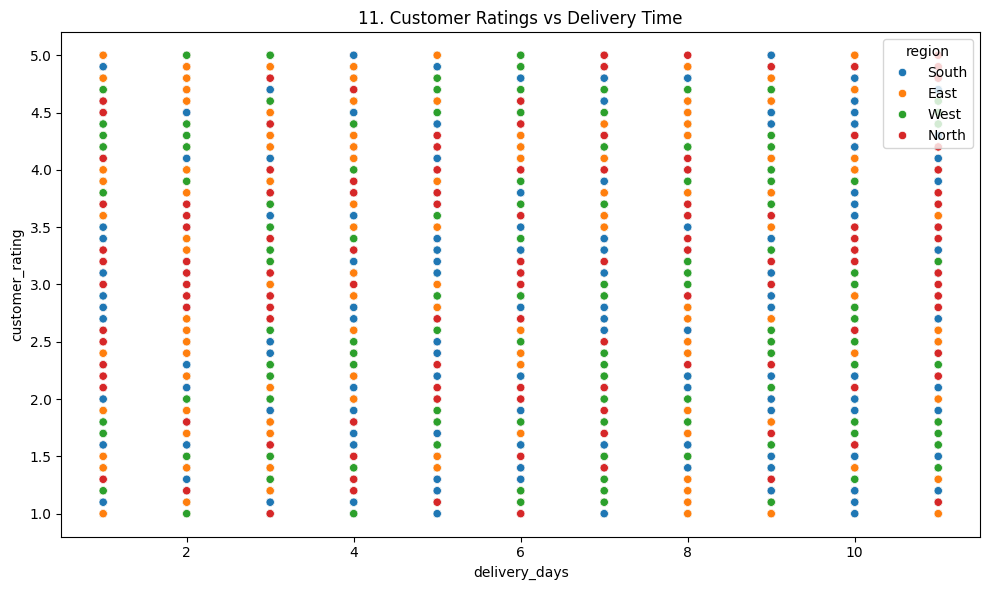

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='delivery_days', y='customer_rating', hue='region')
plt.title(f'{plot_no}. Customer Ratings vs Delivery Time')
show_fig()
plot_no += 1

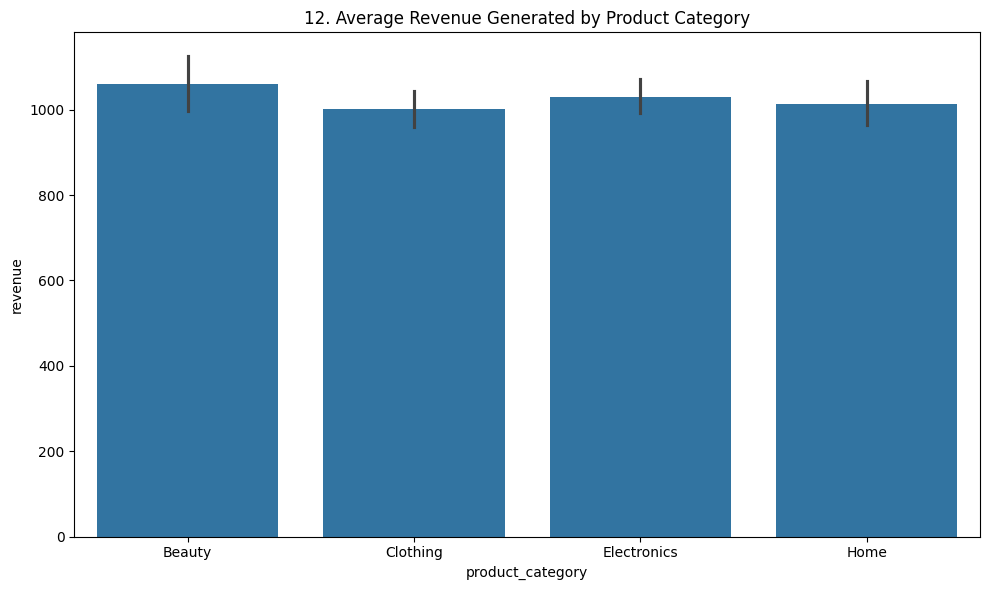

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='product_category', y='revenue', estimator='mean')
plt.title(f'{plot_no}. Average Revenue Generated by Product Category')
show_fig()
plot_no += 1

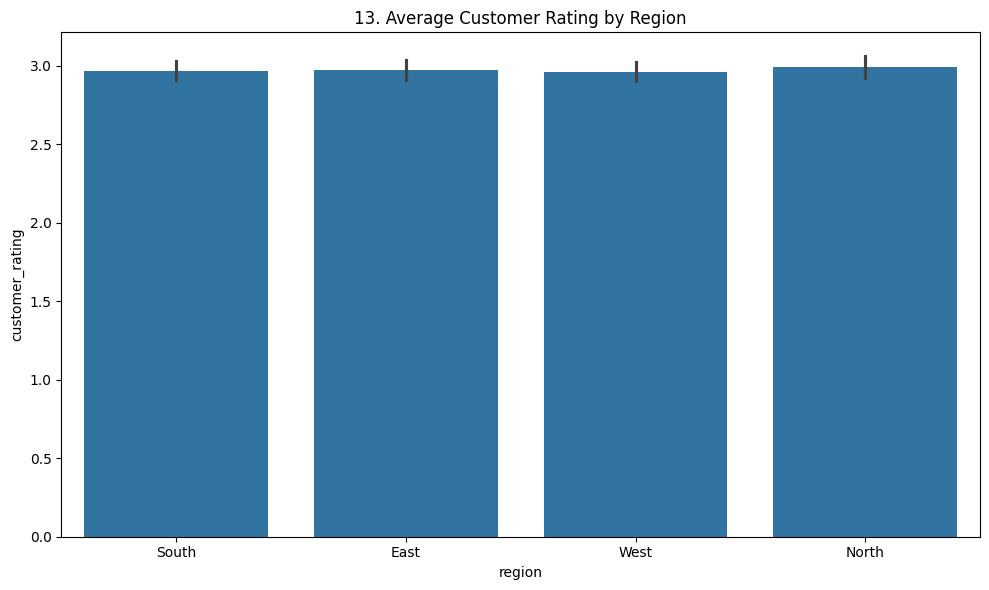

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='region', y='customer_rating', estimator='mean')
plt.title(f'{plot_no}. Average Customer Rating by Region')
show_fig()
plot_no += 1

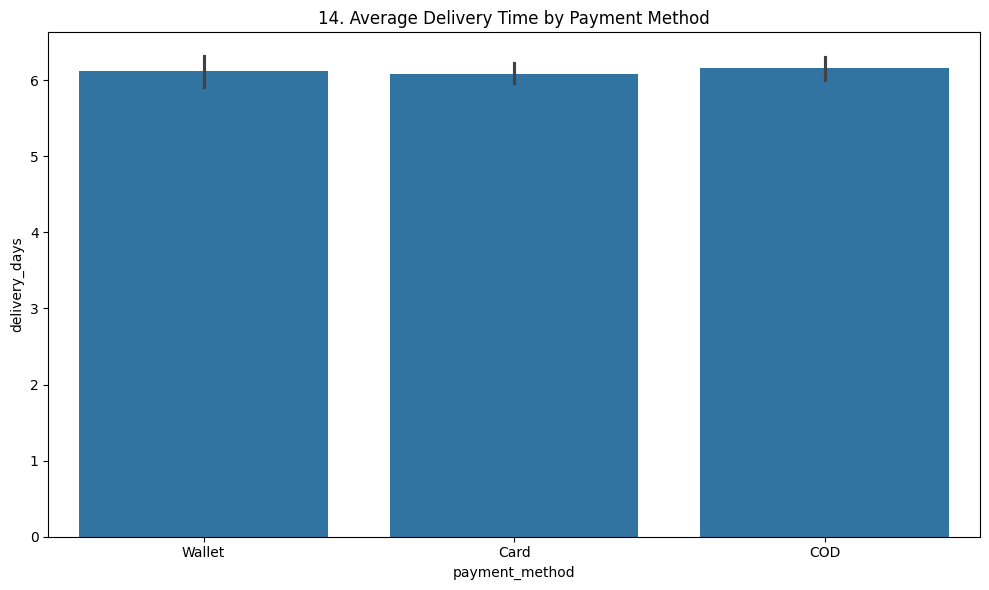

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='payment_method', y='delivery_days', estimator='mean')
plt.title(f'{plot_no}. Average Delivery Time by Payment Method')
show_fig()
plot_no += 1

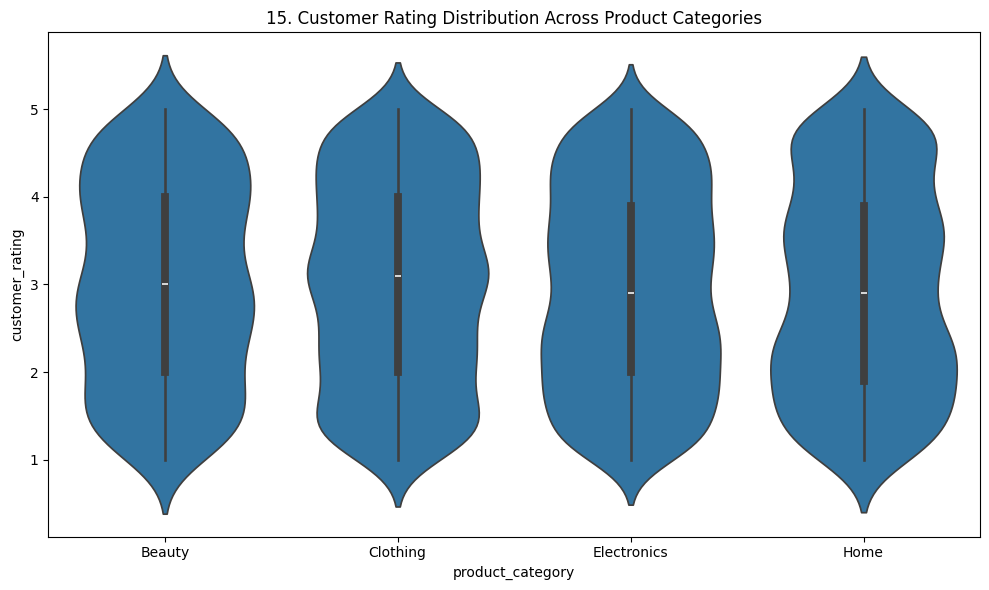

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='product_category', y='customer_rating')
plt.title(f'{plot_no}. Customer Rating Distribution Across Product Categories')
show_fig()
plot_no += 1

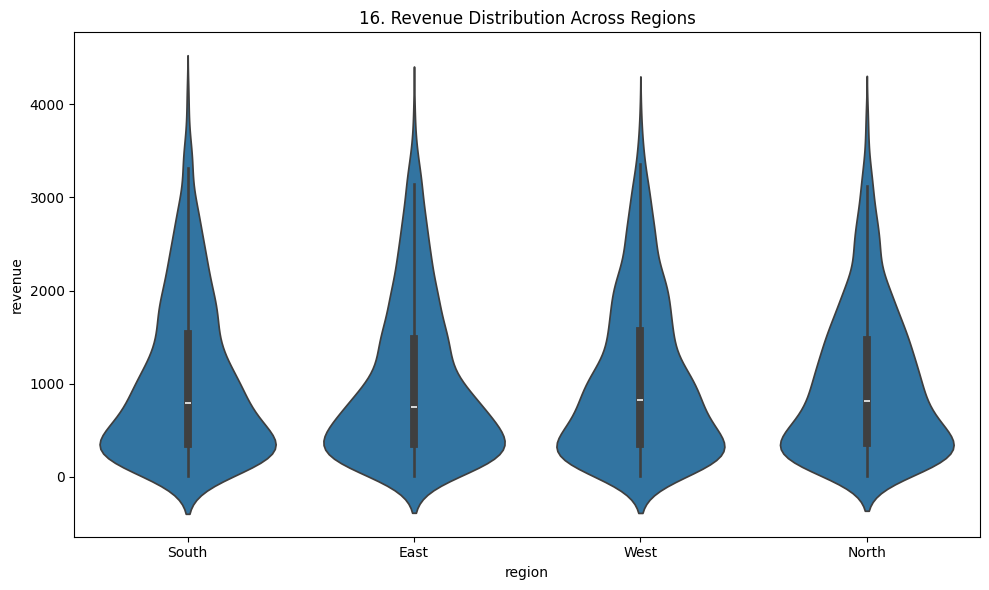

In [28]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='region', y='revenue')
plt.title(f'{plot_no}. Revenue Distribution Across Regions')
show_fig()
plot_no += 1

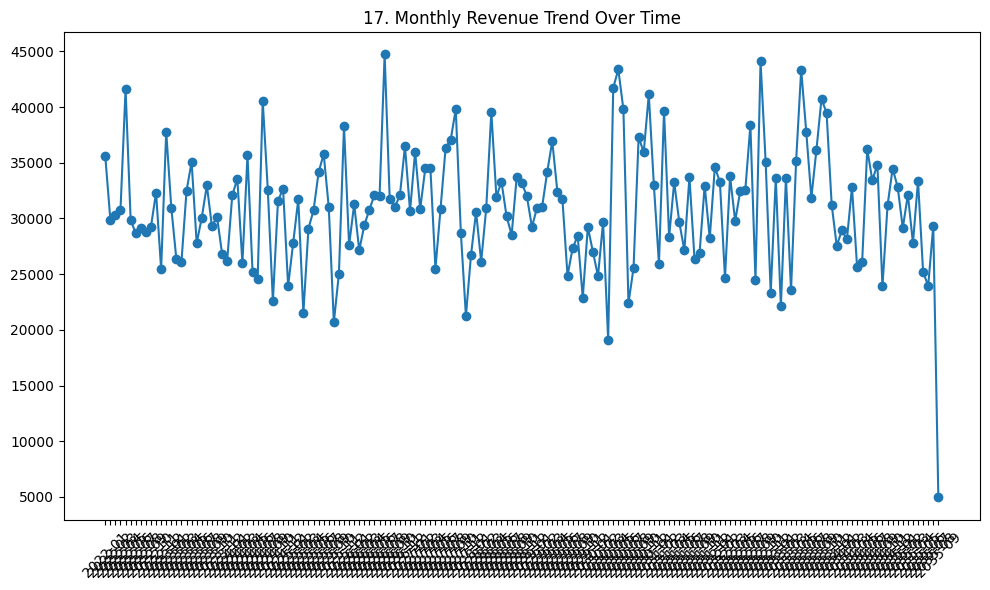

In [29]:
fig = plt.figure(figsize=(10,6))
monthly_sales = df.groupby(pd.to_datetime(df['order_date']).dt.to_period('M'))['revenue'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Monthly Revenue Trend Over Time')
show_fig()
plot_no += 1

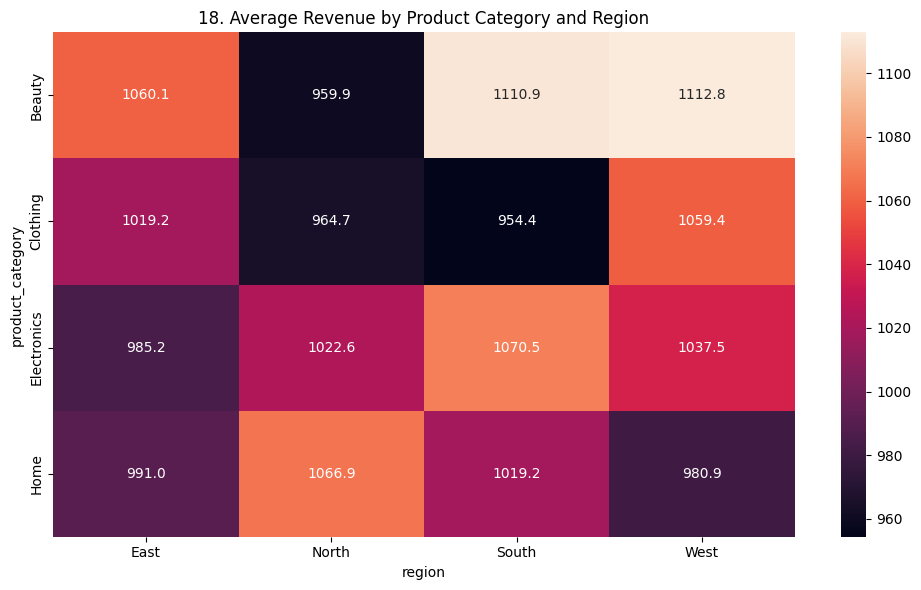

In [30]:
fig = plt.figure(figsize=(10,6))
category_region = df.pivot_table(values='revenue', index='product_category', columns='region', aggfunc='mean')
sns.heatmap(category_region, annot=True, fmt='.1f')
plt.title(f'{plot_no}. Average Revenue by Product Category and Region')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

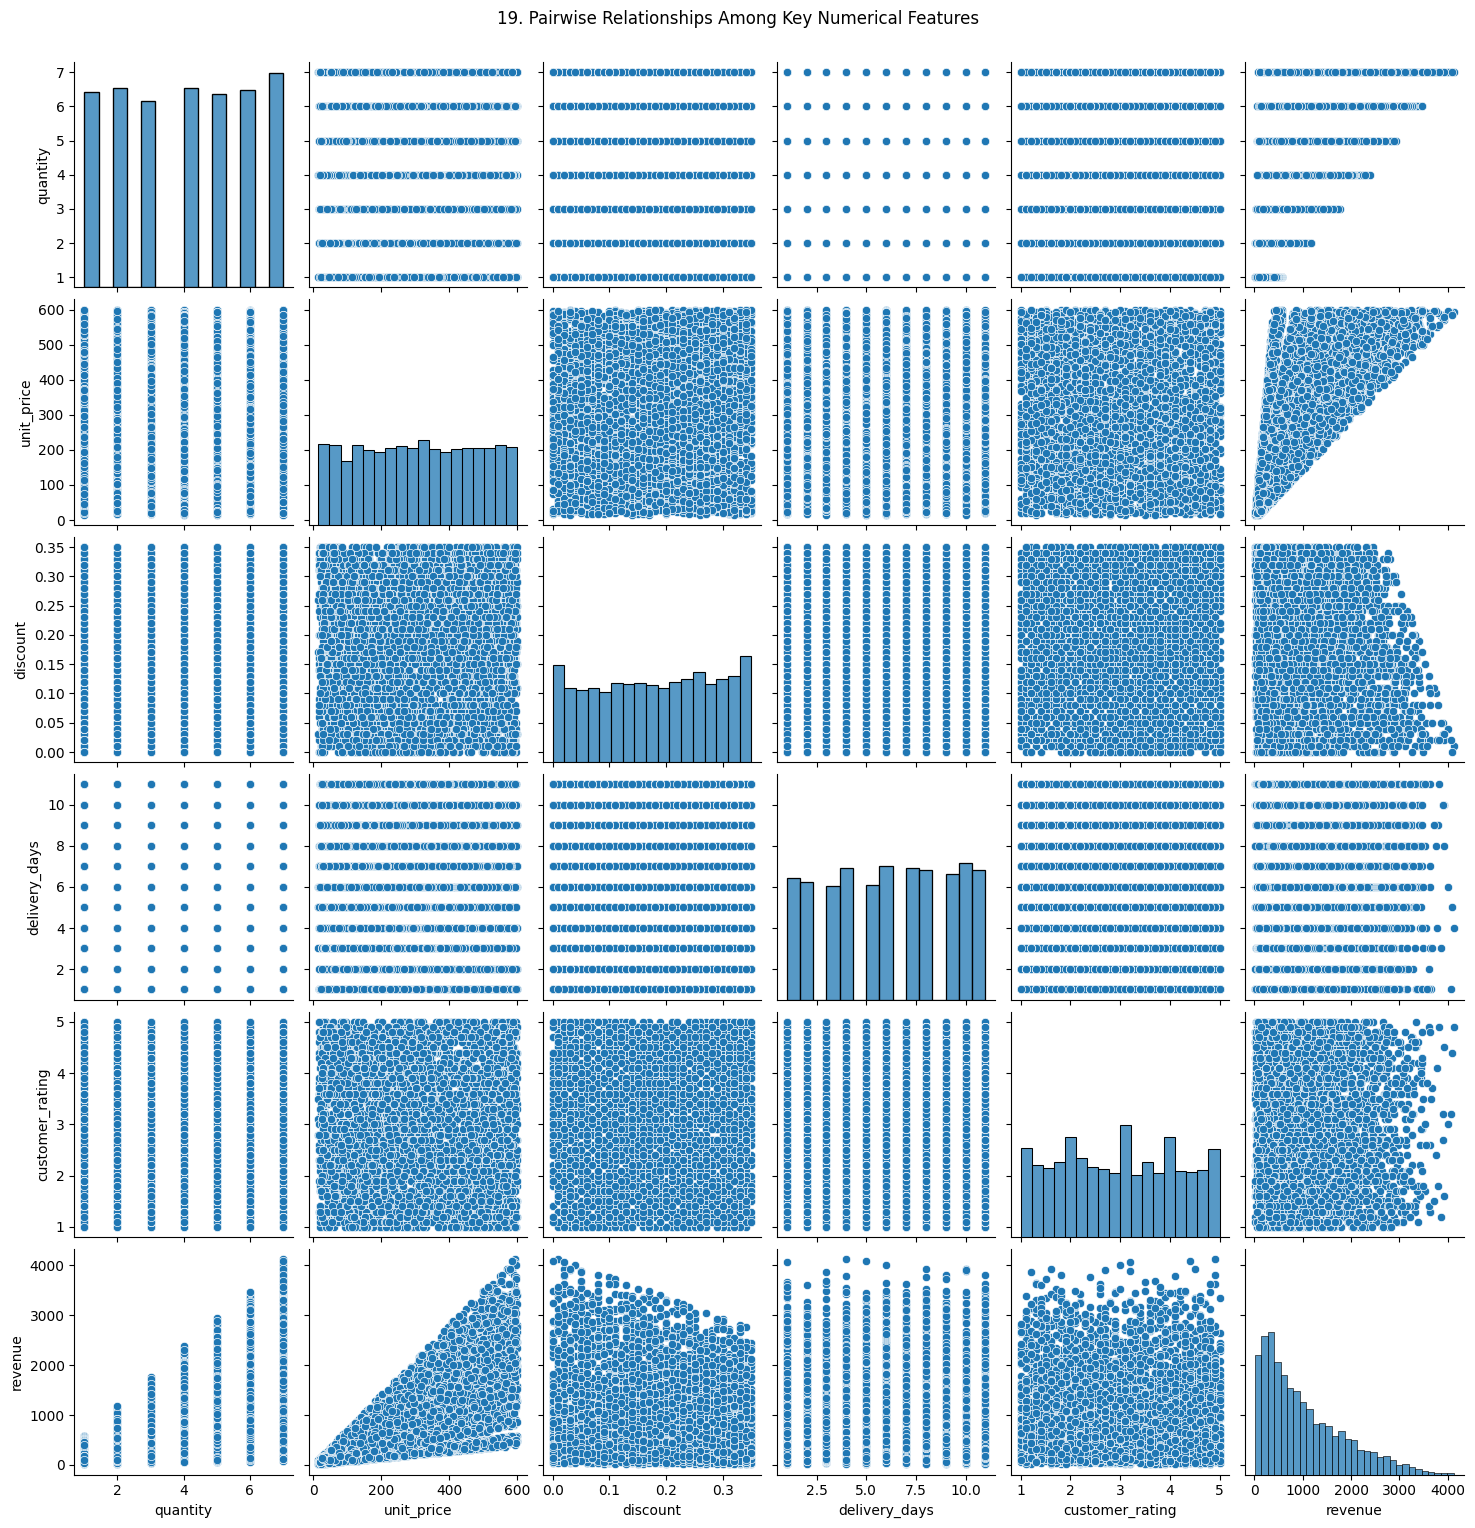

In [31]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['quantity','unit_price','discount','delivery_days','customer_rating','revenue']])
plt.suptitle(f'{plot_no}. Pairwise Relationships Among Key Numerical Features', y=1.02)
plt.show()
plot_no += 1

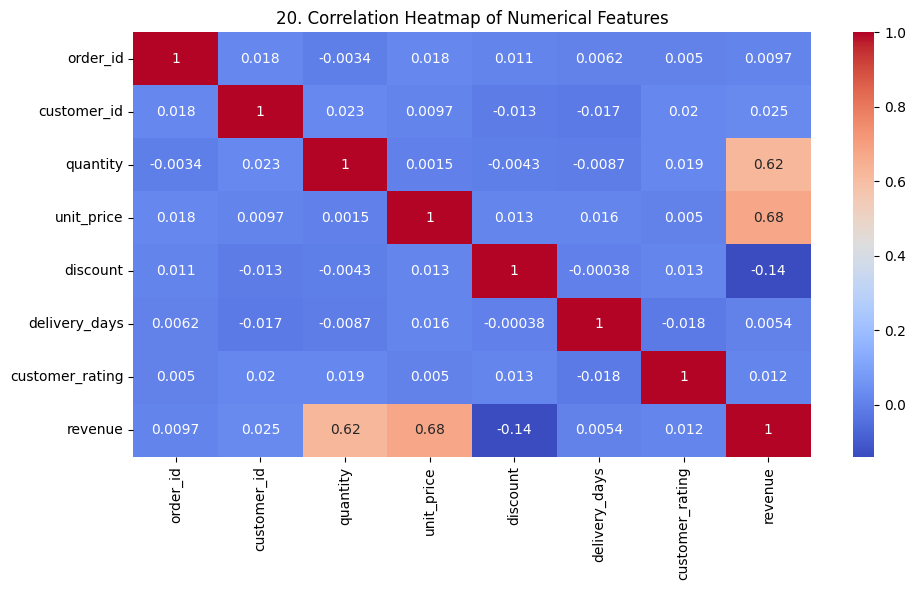

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Separate features and target

In [33]:
X = df.drop('revenue', axis=1)
y = df['revenue']

## Convert order date to useful numerical features

In [34]:
X['order_date'] = pd.to_datetime(X['order_date'])
X['year'] = X['order_date'].dt.year
X['month'] = X['order_date'].dt.month
X['day'] = X['order_date'].dt.day
X['dayofweek'] = X['order_date'].dt.dayofweek
X = X.drop('order_date', axis=1)

## Select numerical and categorical columns

In [35]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Create preprocessing pipeline

In [36]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine preprocessing

In [37]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

## Split the dataset

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build Gradient Boosting pipeline

In [39]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

## Train the model

In [40]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['order_id', 'customer_id', 'quantity', 'unit_price', 'discount',
       'delivery_days', 'customer_rating'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['product_category', 'region', 'payment_method'], dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=300,
                                           random_state=42))])

## Make predictions

In [41]:
y_pred = model.predict(X_test)

## Print model performance

In [42]:
print(f'R² Score : {r2_score(y_test, y_pred):.4f}')
print(f'MAE      : {mean_absolute_error(y_test, y_pred):.2f}')
print(f'RMSE     : {mean_squared_error(y_test, y_pred) ** 0.5:.2f}')

R² Score : 0.9993
MAE      : 17.07
RMSE     : 22.35


## Plot Actual vs Predicted

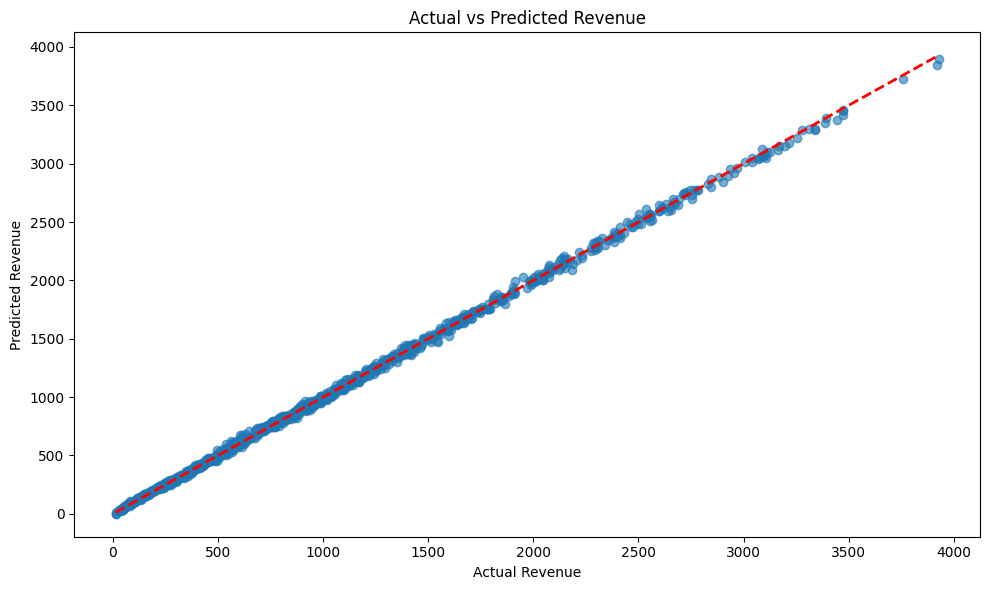

In [43]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.tight_layout()
plt.show()